<a href="https://colab.research.google.com/github/Marteldelfer/PISI3/blob/main/SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt

In [3]:
# === 1. Carregar os dados ===
try:
    df = pd.read_csv("tmdb_new.csv")
except FileNotFoundError:
    print("Erro: O arquivo 'tmdb_new.csv' não foi encontrado.")
    exit()

# === 2. Remover colunas indesejadas ===
colunas_remover = [
    'id', 'title', 'release_date', 'music_composer', 'producers',
    'writers', 'original_language', 'production_companies',
    'production_countries', 'cast', 'director',
    'director_of_photography','imdb_rating', 'imdb_votes'
]
df = df.drop(columns=[col for col in colunas_remover if col in df.columns])

# === 3. Simplificar a coluna 'genres' ===
if 'genres' in df.columns:
    df['genres'] = df['genres'].apply(
        lambda x: x.split(',')[0].strip() if pd.notna(x) else x
    )

# === 4. Definir variável alvo e features ===
target = 'revenue'
y = df[target]
X = df.drop(columns=[target])

# === 5. Separar colunas numéricas e categóricas ===
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# === 6. Criar o pré-processador ===
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore',
            max_categories=10
        ))
    ]), cat_cols)
], remainder='passthrough')


df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12020 entries, 0 to 12019
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vote_average       12020 non-null  float64
 1   vote_count         12020 non-null  float64
 2   revenue            12020 non-null  float64
 3   runtime            12020 non-null  float64
 4   budget             12020 non-null  float64
 5   popularity         12020 non-null  float64
 6   genres             12020 non-null  object 
 7   profit_percentage  12020 non-null  float64
dtypes: float64(7), object(1)
memory usage: 751.4+ KB


In [4]:
# === 7. Criar e treinar o pipeline completo ===
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    ))
])

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)

# Treinar o modelo
print("Treinando o modelo...")
pipeline.fit(X_train, y_train)
print("Treinamento concluído.")



Treinando o modelo...
Treinamento concluído.


In [5]:
# === 8. Análise com SHAP ===
print("Calculando os valores SHAP...")
model = pipeline.named_steps['model']
preprocessor_fitted = pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names = preprocessor_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)
print("Cálculo SHAP concluído.")

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

Calculando os valores SHAP...
Cálculo SHAP concluído.


100%|===================| 8406/8414 [04:35<00:00]       

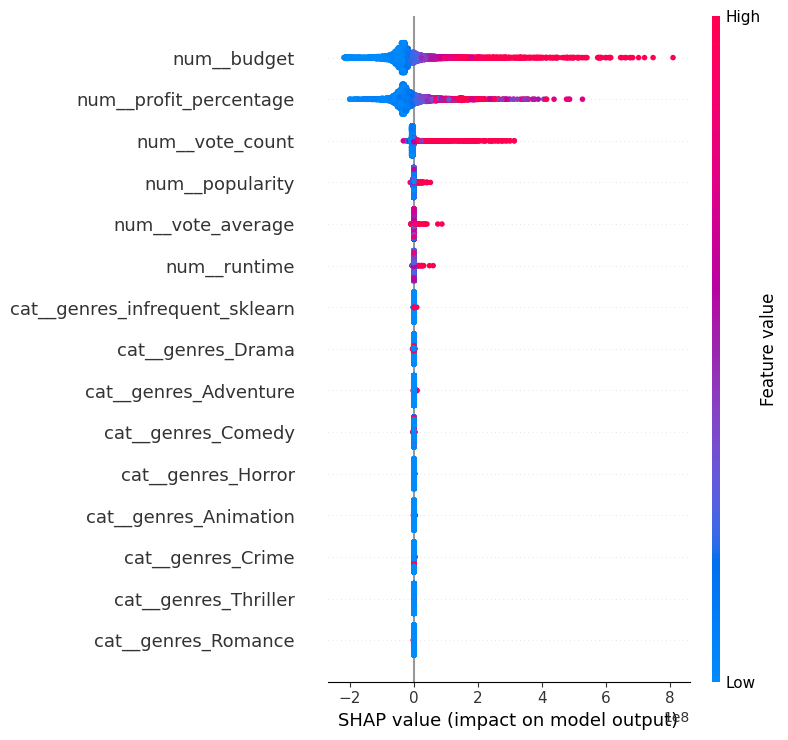

In [6]:
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(pipeline.named_steps['model'], data=X_train_transformed)

# Aqui você passa check_additivity=False ao calcular os valores SHAP
shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out()
)


Calculando os valores SHAP...


100%|===================| 8407/8414 [04:18<00:00]       

Cálculo SHAP concluído.
Agregando os valores SHAP para a feature 'genre'...
Traduzindo os nomes das features...

Exibindo o gráfico de resumo


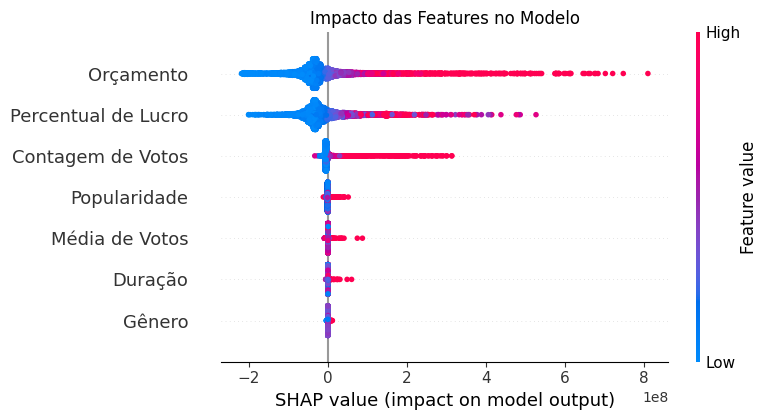

In [7]:
# 1. Transforme os dados e calcule os valores SHAP
print("Calculando os valores SHAP...")
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(pipeline.named_steps['model'], data=X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

# Obtenha os nomes das features
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
print("Cálculo SHAP concluído.")

# 2. Lógica para agregar os valores SHAP de gênero
print("Agregando os valores SHAP para a feature 'genre'...")
genre_cols = [col for col in feature_names if col.startswith('cat__genres_')]
other_cols = [col for col in feature_names if not col.startswith('cat__genres_')]

genre_indices = [list(feature_names).index(col) for col in genre_cols]
other_indices = [list(feature_names).index(col) for col in other_cols]

shap_values_genre_aggregated = shap_values[:, genre_indices].sum(axis=1)
shap_values_others = shap_values[:, other_indices]
aggregated_shap_values = np.c_[shap_values_others, shap_values_genre_aggregated]
aggregated_feature_names = other_cols + ['Genre']

# 3. Crie a matriz de "valores de feature" para a coloração especial
other_feature_values = X_test_transformed_df[other_cols].values
aggregated_feature_values_for_plot = np.c_[other_feature_values, shap_values_genre_aggregated]
aggregated_features_df = pd.DataFrame(
    aggregated_feature_values_for_plot,
    columns=aggregated_feature_names
)

# 4. **DICIONÁRIO DE TRADUÇÃO ATUALIZADO**
print("Traduzindo os nomes das features...")
translation_dict = {
    # Features numéricas
    'num__popularity': 'Popularidade',
    'num__budget': 'Orçamento',
    'num__runtime': 'Duração',
    'num__vote_count': 'Contagem de Votos',
    'num__vote_average': 'Média de Votos',
    'num__profit_percentage': 'Percentual de Lucro',
    'num__revenue_to_budget_ratio': 'Proporção Receita/Orçamento',

    # Feature agregada
    'Genre': 'Gênero'
}

# A tradução é feita na lista final de features agregadas
translated_feature_names = [translation_dict.get(name, name) for name in aggregated_feature_names]

# O DataFrame para plotagem também recebe os nomes traduzidos
aggregated_features_df.columns = translated_feature_names

# 5. Gere o gráfico de resumo final com a tradução
print("\nExibindo o gráfico de resumo")
plt.title("Impacto das Features no Modelo")

shap.summary_plot(
    aggregated_shap_values,
    features=aggregated_features_df,
    show=False
)
plt.tight_layout()
plt.show()

Agregando os valores SHAP para a feature 'genre'...

Exibindo o gráfico de resumo SHAP com gênero agregado...


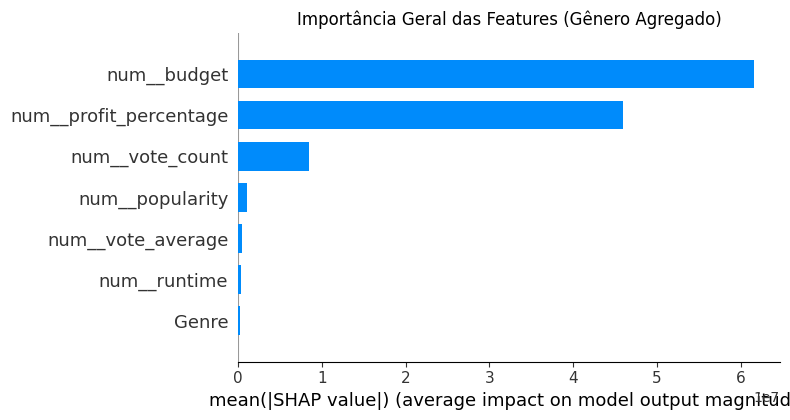


Exibindo o gráfico de dependência para 'num__budget'
Os pontos serão coloridos pela feature de interação: 'num__profit_percentage'


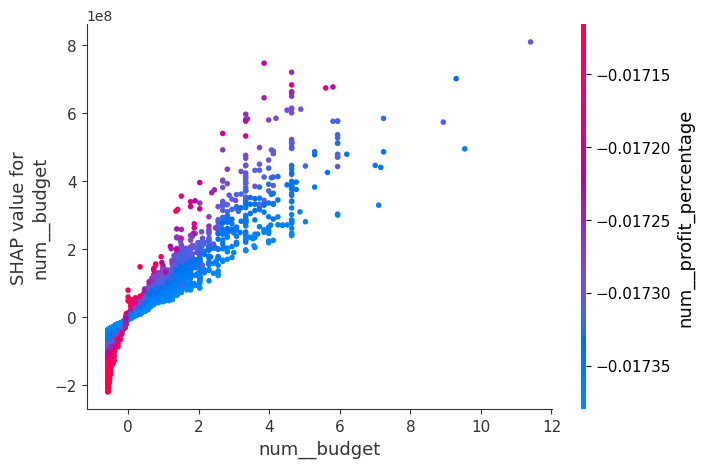

In [8]:
# === 9. **NOVO**: Agregar valores SHAP para Gênero ===
print("Agregando os valores SHAP para a feature 'genre'...")

# Identificar colunas relacionadas a gênero e outras colunas
genre_cols = [col for col in feature_names if col.startswith('cat__genres_')]
other_cols = [col for col in feature_names if not col.startswith('cat__genres_')]

# Encontrar os índices das colunas
genre_indices = [list(feature_names).index(col) for col in genre_cols]
other_indices = [list(feature_names).index(col) for col in other_cols]

# Somar os valores SHAP das colunas de gênero
shap_values_genre_aggregated = shap_values[:, genre_indices].sum(axis=1)

# Manter os valores SHAP das outras colunas
shap_values_others = shap_values[:, other_indices]

# Combinar os SHAP values: outros + gênero agregado
aggregated_shap_values = np.c_[shap_values_others, shap_values_genre_aggregated]

# Criar nova lista de nomes de features para o gráfico
aggregated_feature_names = other_cols + ['Genre']


# === 10. Gerar Gráfico de Resumo SHAP com Gênero Agregado ===
print("\nExibindo o gráfico de resumo SHAP com gênero agregado...")
plt.title("Importância Geral das Features (Gênero Agregado)")

# Usamos os novos SHAP values e nomes de features para o gráfico
shap.summary_plot(aggregated_shap_values, feature_names=aggregated_feature_names, plot_type="bar")


# === 11. Gerar Gráfico de Dependência SHAP (sem alterações) ===
# O gráfico de dependência ainda usa as features originais e mais importantes
sorted_feature_indices = np.argsort(np.abs(shap_values).mean(0))
most_important_feature_name = feature_names[sorted_feature_indices[-1]]
second_most_important_feature_name = feature_names[sorted_feature_indices[-2]]

print(f"\nExibindo o gráfico de dependência para '{most_important_feature_name}'")
print(f"Os pontos serão coloridos pela feature de interação: '{second_most_important_feature_name}'")

shap.dependence_plot(
    most_important_feature_name,
    shap_values,
    X_test_transformed_df,
    interaction_index=second_most_important_feature_name
)